<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/Dairy/CowsAnomalyDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install torch torchvision pytorchvideo decord



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 17.1 MB/s eta 0:00:00
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=e03a2d9ed944f66bfa37f4ff0243fa8e388cf451d2d6d65a7ad9e8a5077ff8ec
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=81639c485dbc415919a34db8775835c9bf4bec02b15c8c39fd9c663deabdea02
  Stored in directory: /root/.cache/pip/wheel

In [ ]:
!pip install opencv-python tqdm pandas

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("fandaoerji/cbvd-5cow-behavior-video-dataset")
print(path)
import os

for d in os.listdir(path):
    print(d)

Using Colab cache for faster access to the 'cbvd-5cow-behavior-video-dataset' dataset.
/kaggle/input/cbvd-5cow-behavior-video-dataset
labelframes
minilabelframes
labelframes_add
videos
annotations
rawframes_mini
videos_add
CBVD-5.csv
miniannotations


In [ ]:
import os


print("Dataset root path:", path)


print("\nDataset structure preview:")
for root, dirs, files in os.walk(path):
    if files:
        rel = os.path.relpath(root, path)
        print(f"{rel}/  → {len(files)} files (first 3: {files[:3]})")


DATA_ROOT = path
ANNOTATIONS_DIR = os.path.join(path, "annotations")
VIDEO_DIR = os.path.join(path, "video_cut")
RAWFRAMES_DIR = os.path.join(path, "rawframes")

print(f"\n Paths ready:")
print(f"   DATA_ROOT       = {DATA_ROOT}")
print(f"   ANNOTATIONS_DIR = {ANNOTATIONS_DIR}")
print(f"   VIDEO_DIR       = {VIDEO_DIR}")

Dataset root path: /kaggle/input/cbvd-5cow-behavior-video-dataset

Dataset structure preview:
./  → 1 files (first 3: ['CBVD-5.csv'])
labelframes/labelframes/  → 4122 files (first 3: ['639_00002.jpg', '101_00003.jpg', '396_00003.jpg'])
minilabelframes/  → 4122 files (first 3: ['639_00002.jpg', '101_00003.jpg', '396_00003.jpg'])
labelframes_add/labelframes/  → 1200 files (first 3: ['784_00002.jpg', '895_00005.jpg', '885_00003.jpg'])
videos/videos/  → 687 files (first 3: ['123.mp4', '479.mp4', '660.mp4'])
annotations/  → 11 files (first 3: ['ava_test_v2.1.csv', 'ava_dense_proposals_test.FAIR.recall_93.9.pkl', 'ava_dense_proposals_val.FAIR.recall_93.9.pkl'])
rawframes_mini/437/  → 300 files (first 3: ['img_00031.jpg', 'img_00243.jpg', 'img_00037.jpg'])
rawframes_mini/515/  → 300 files (first 3: ['img_00031.jpg', 'img_00243.jpg', 'img_00037.jpg'])
rawframes_mini/248/  → 300 files (first 3: ['img_00031.jpg', 'img_00243.jpg', 'img_00037.jpg'])
rawframes_mini/625/  → 300 files (first 3: ['img

In [ ]:
DATA_ROOT = path

ANNOTATIONS_DIR = os.path.join(DATA_ROOT, "miniannotations")
FRAMES_DIR = os.path.join(DATA_ROOT, "rawframes_mini")

print(os.listdir(ANNOTATIONS_DIR))
ann_file = None

for f in os.listdir(ANNOTATIONS_DIR):
    if f.endswith(".csv"):
        ann_file = os.path.join(ANNOTATIONS_DIR, f)
        break

print("Using:", ann_file)

['ava_test_v2.1.csv', 'ava_dense_proposals_test.FAIR.recall_93.9.pkl', 'ava_dense_proposals_val.FAIR.recall_93.9.pkl', 'ava_train_excluded_timestamps_v2.1.csv', 'ava_test_excluded_timestamps_v2.1.csv', 'ava_action_list_v2.1_for_activitynet_2018.pbtxt', 'ava_val_excluded_timestamps_v2.1.csv', 'ava_dense_proposals_train.FAIR.recall_93.9.pkl', 'labelmap.txt', 'ava_train_v2.1.csv', 'ava_val_v2.1.csv']
Using: /kaggle/input/cbvd-5cow-behavior-video-dataset/miniannotations/ava_test_v2.1.csv


In [ ]:
import pandas as pd

df = pd.read_csv(ann_file, header=None, dtype={0: str})

df.columns = [
    "video_id",
    "timestamp",
    "x1", "y1", "x2", "y2",
    "action_id",
    "target_id"
]

print(df.head())
print("Total samples:", len(df))

  video_id  timestamp        x1        y1        x2        y2  action_id  \
0      393          4  0.328125  0.226562  0.414062  0.359375          2   
1      393          4  0.328125  0.226562  0.414062  0.359375          5   
2      393          4  0.304688  0.199219  0.378906  0.296875          2   
3      393          4  0.304688  0.199219  0.378906  0.296875          5   
4      393          4  0.218750  0.218750  0.304688  0.292969          2   

   target_id  
0          1  
1          1  
2          1  
3          1  
4          1  
Total samples: 3761


In [ ]:
import os

print("Sample frame folders:")
print(os.listdir(FRAMES_DIR)[:20])
print("Sample video_ids from annotations:")
print(df["video_id"].head(20).tolist())

Sample frame folders:
['437', '515', '248', '625', '7', '135', '47', '479', '183', '642', '313', '600', '17', '81', '466', '494', '19', '199', '480', '121']
Sample video_ids from annotations:
['393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393']


In [ ]:
valid_ids = set(os.listdir(FRAMES_DIR))

print("Number of frame folders:", len(valid_ids))

Number of frame folders: 686


In [ ]:
df["video_id"] = df["video_id"].apply(lambda x: str(int(x)))

df = df[df["video_id"].isin(valid_ids)]

print("Filtered dataset size:", len(df))

Filtered dataset size: 3761


Video dir exists: False


In [ ]:
import torch
from torch.utils.data import Dataset
import os
import cv2

class CowDatasetBBox(Dataset):
    def __init__(self, df, frames_dir, num_frames=8, fps=25):
        self.df = df.reset_index(drop=True)
        self.frames_dir = frames_dir
        self.num_frames = num_frames
        self.fps = fps

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        video_id = str(int(row.video_id))
        video_folder = os.path.join(self.frames_dir, video_id)

        if not os.path.exists(video_folder):
            # fail-safe
            return torch.zeros((self.num_frames, 3, 112, 112)), 0

        frame_files = sorted(os.listdir(video_folder))

        if len(frame_files) == 0:
            return torch.zeros((self.num_frames, 3, 112, 112)), 0

        # 🎯 Align with timestamp
        center_idx = int(row.timestamp * self.fps)

        # clamp index
        center_idx = min(max(center_idx, 0), len(frame_files) - 1)

        start = max(0, center_idx - self.num_frames // 2)
        end = min(len(frame_files), start + self.num_frames)

        selected_frames = frame_files[start:end]

        frames = []

        for f in selected_frames:
            img_path = os.path.join(video_folder, f)
            img = cv2.imread(img_path)

            if img is None:
                continue

            h, w, _ = img.shape


            x1 = int(row.x1 * w)
            y1 = int(row.y1 * h)
            x2 = int(row.x2 * w)
            y2 = int(row.y2 * h)

            # clamp bbox (VERY important)
            x1 = max(0, min(x1, w-1))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h-1))
            y2 = max(0, min(y2, h))

            if x2 <= x1 or y2 <= y1:
                continue  # skip invalid bbox

            # crop
            img = img[y1:y2, x1:x2]

            # resize
            img = cv2.resize(img, (112, 112))

            # normalize
            img = img / 255.0

            frames.append(img)

        # pad if needed
        if len(frames) < self.num_frames:
            pad = [frames[-1]] * (self.num_frames - len(frames)) if frames else [torch.zeros(112,112,3).numpy()] * self.num_frames
            frames.extend(pad)

        frames = torch.tensor(frames).permute(0, 3, 1, 2).float()

        label = int(row.action_id) - 1

        return frames, label

In [ ]:
import torch.nn as nn

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)
        x = self.conv(x)
        return self.fc(x)

In [ ]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

In [ ]:
from torch.utils.data import random_split, DataLoader

dataset = CowDatasetBBox(df.sample(3000), FRAMES_DIR)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Simple3DCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for frames, labels in train_loader:
        frames, labels = frames.to(device), labels.to(device)

        preds = model(frames)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(preds, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)

            preds = model(frames)
            loss = criterion(preds, labels)

            val_loss += loss.item()

            _, predicted = torch.max(preds, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    print("-" * 40)

/tmp/ipykernel_3387/1249741293.py:84: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  frames = torch.tensor(frames).permute(0, 3, 1, 2).float()


Epoch 1/10
Train Loss: 1.1096, Train Acc: 0.5154
Val   Loss: 1.1014, Val   Acc: 0.5100
----------------------------------------
Epoch 2/10
Train Loss: 0.8743, Train Acc: 0.5871
Val   Loss: 0.8902, Val   Acc: 0.5700
----------------------------------------
Epoch 3/10
Train Loss: 0.7977, Train Acc: 0.5925
Val   Loss: 0.8386, Val   Acc: 0.5683
----------------------------------------
Epoch 4/10
Train Loss: 0.7441, Train Acc: 0.6112
Val   Loss: 0.8040, Val   Acc: 0.5683
----------------------------------------
Epoch 5/10
Train Loss: 0.7176, Train Acc: 0.6104
Val   Loss: 0.8119, Val   Acc: 0.5550
----------------------------------------
Epoch 6/10
Train Loss: 0.6943, Train Acc: 0.6304
Val   Loss: 0.7968, Val   Acc: 0.5567
----------------------------------------
Epoch 7/10
Train Loss: 0.6591, Train Acc: 0.6388
Val   Loss: 0.7810, Val   Acc: 0.5800
----------------------------------------
Epoch 8/10
Train Loss: 0.6315, Train Acc: 0.6546
Val   Loss: 0.8456, Val   Acc: 0.5233
-----------------

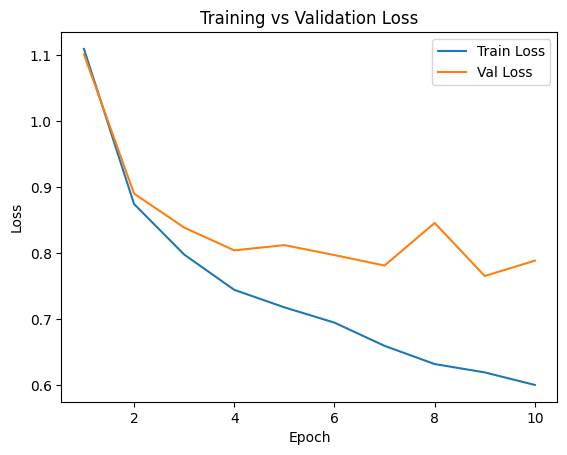

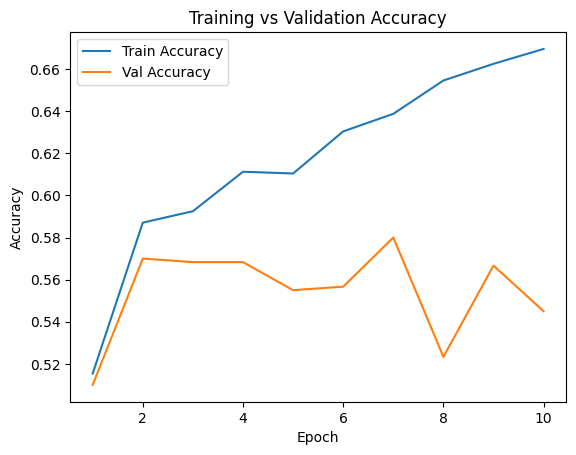

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()